# NMD Rate Model: Project Overview

A **Bayesian, state-space, hierarchical** model for non-maturing-deposit (NMD)
rates and volumes, built on real ECB AAA government-bond yield curve data
(2014–2024).

## Why this matters

Non-maturing deposits (current and savings accounts) are a bank's largest and
cheapest funding source, but they carry hidden interest-rate risk because:

- The bank sets the deposit rate **administratively**, with delays, while
  market rates move continuously.
- **Pass-through** is heterogeneous across customer segments: corporates are
  rate-sensitive, retail current-account holders are not.
- During hiking cycles, depositors can withdraw and shift to higher-yielding
  alternatives. **Deposit volumes** are a function of the same dynamics.

Modelling this matters for:

- **IRRBB** (Interest Rate Risk in the Banking Book): how does Net Interest
  Income (NII) move under stress?
- **ALM** and **liquidity planning**: how sticky are these deposits really?
- **Economic value of equity (EVE)** under standard regulatory shocks.

## The three stages of the model

```
                                  +-----------------------+
                                  |  IRRBB scenarios      |
                                  |  (5 rate shocks)      |
                                  +-----------+-----------+
                                              |
                                              v
+-----------+    Diebold-Li    +-------------+    Hierarchical ECM     +--------+    Hierarchical AR(1)    +---------+
|  ECB      |  State-space     |  Latent     |  + Markov regimes       |        |    + spread sensitivity   |         |
|  yields   | -------------->  |  factors    | --------------------->  |  Rates | ----------------------->  | Volumes |
|  (T x J)  |  Kalman + NUTS   |  L, S, C    |  Hamilton filter        |        |    LogNormal sigma priors |   NII   |
+-----------+                  +-------------+                         +--------+                           +---------+
```

Each stage is what a recruiter or future employer probably cares about:

| Stage | Novel feature | Why it matters |
|---|---|---|
| **1. Yield curve** | Bayesian state-space (Kalman in `pytensor.scan`, NUTS in PyMC) | Full posterior on factor dynamics. Smoother factors than OLS, joint uncertainty |
| **2. Segments** | Hierarchical ECM + **Markov regime switching**, Hamilton filter marginalisation | Captures the structural break between zero-rate era and hiking cycle; partial pooling across 4 segments |
| **3. Volumes** | Hierarchical AR(1) with **soft regime covariate** from stage 2 | Re-uses the Hamilton-filter probabilities: no second latent state to estimate |

The rest of this notebook walks through each stage with its equations and
headline results. All trained models are loaded from `../data/*.pkl`
(produced by notebooks 02 → 06).


In [1]:
import sys
sys.path.insert(0, "../src")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from simulate import (
    SEGMENTS, MATURITIES, TRUE_GAMMA, TRUE_BETA_L_R1,
    TRUE_BETA_L_R0,
)
from diebold_li import LAMBDA_MAT
from volume import TRUE_RHO, TRUE_BETA_V_R0, TRUE_BETA_V_R1

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
SEG_COLORS      = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
SCENARIO_COLORS = ["#333333", "#d62728", "#1f77b4", "#8c564b", "#bcbd22"]

with open("../data/ecb_data.pkl",         "rb") as f: ecb  = pickle.load(f)
with open("../data/dl_results.pkl",       "rb") as f: dl   = pickle.load(f)
with open("../data/ecm_results.pkl",      "rb") as f: ecm  = pickle.load(f)
with open("../data/pipeline_results.pkl", "rb") as f: pipe = pickle.load(f)
with open("../data/volume_results.pkl",   "rb") as f: vol  = pickle.load(f)

yields           = ecb["yields"]
deposits         = ecb["deposits"]
regime_true      = ecb["regime_seq"].values
factors_filtered = dl["factors_filtered"]
idata_ecm        = ecm["idata"]
xi_filtered      = ecm["xi_filtered"]
idata_vol        = vol["idata"]
volumes_df       = vol["volumes_hist"]
dates            = yields.index

print(f"Period: {dates[0].date()} -> {dates[-1].date()}  ({len(dates)} months, {yields.shape[1]} maturities)")
print(f"Segments: {SEGMENTS}")


Period: 2014-01-01 -> 2024-12-01  (132 months, 8 maturities)
Segments: ['Retail Current', 'Retail Savings', 'SME Operational', 'Corporate']


---

## Part 1: Yield curve: Bayesian state-space Diebold-Li

### Nelson-Siegel parameterisation

The yield at time $t$ and maturity $\tau$ is a three-factor decomposition:

$$
y_t(\tau) \;=\; L_t \;+\; S_t\cdot\ell_1(\tau) \;+\; C_t\cdot\ell_2(\tau),
\qquad
\ell_1(\tau)=\tfrac{1-e^{-\lambda\tau}}{\lambda\tau},\;
\ell_2(\tau)=\ell_1(\tau)-e^{-\lambda\tau}.
$$

The factors carry economic meaning: $L_t$ = level (long-run rate),
$S_t$ = slope (short minus long), $C_t$ = curvature (medium-maturity hump).
We fix $\lambda = 0.0609$ (the standard monthly choice).

### Diebold-Li state-space form

Diebold & Li (2006) treat the three factors as **latent states** with VAR(1)
dynamics:

$$
\underbrace{\mathbf{y}_t}_{J\times 1}
\;=\; \boldsymbol{\Lambda}\,\mathbf{f}_t \;+\; \boldsymbol{\varepsilon}_t,
\qquad
\boldsymbol{\varepsilon}_t \sim \mathcal N(\mathbf 0,\sigma^2_{\text{obs}}\mathbf I_J)
\qquad\text{(observation)}
$$

$$
\mathbf{f}_t \;=\; \boldsymbol{\mu} \;+\; \boldsymbol{\Phi}(\mathbf{f}_{t-1}-\boldsymbol{\mu}) \;+\; \boldsymbol{\eta}_t,
\qquad
\boldsymbol{\eta}_t \sim \mathcal N(\mathbf 0, \mathbf Q)
\qquad\text{(state)}
$$

with $\boldsymbol{\Lambda}\in\mathbb R^{J\times 3}$ the fixed Nelson-Siegel
loading matrix. We use diagonal $\boldsymbol{\Phi}$ and $\mathbf Q$.

### Why Bayesian and why Kalman?

- The Kalman filter delivers the **exact marginal likelihood**
  $p(\mathbf{y}_{1:T}\mid\boldsymbol\theta)$ by integrating out the latent
  factors analytically:
  $$
  \log p(\mathbf{Y}\mid\boldsymbol\theta) = \sum_{t=1}^{T}\!\left[
  -\tfrac{J}{2}\log 2\pi
  -\tfrac{1}{2}\log|\mathbf S_t|
  -\tfrac{1}{2}\mathbf v_t^\top \mathbf S_t^{-1}\mathbf v_t
  \right].
  $$
- Wrapping this likelihood in PyMC and sampling with NUTS gives the **full
  posterior** over $(\boldsymbol{\mu},\boldsymbol{\Phi},\mathbf Q,\sigma_{\text{obs}})$,
  not just point estimates. Forecast uncertainty propagates correctly into
  the downstream models.
- Implementation: the entire Kalman recursion lives inside `pytensor.scan` so
  that NUTS can autodifferentiate through it (no manual gradients).


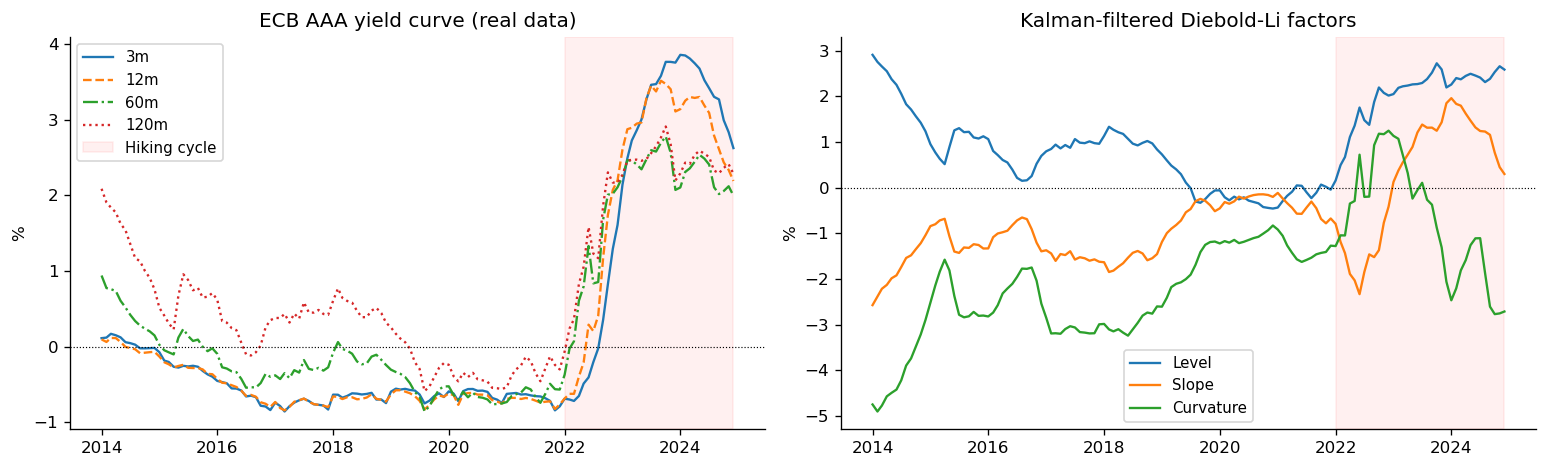

Yield curve fit RMSE: 0.0661 pp  (over 132 months x 8 maturities)
Level posterior mean: 1.05%
Persistence diag(Phi): factors are highly persistent — the level factor
  swings from ~-1% (2015-2019 negative rate era) to ~4% (post-2022 hikes).


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for col, ls in zip(["3m", "12m", "60m", "120m"], ["-", "--", "-.", ":"]):
    ax.plot(yields.index, yields[col], lw=1.4, ls=ls, label=col)
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red",
           label="Hiking cycle")
ax.set_title("ECB AAA yield curve (real data)")
ax.set_ylabel("%"); ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax = axes[1]
for col, color in zip(["Level", "Slope", "Curvature"], ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    ax.plot(factors_filtered.index, factors_filtered[col], color=color, lw=1.4, label=col)
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
ax.set_title("Kalman-filtered Diebold-Li factors")
ax.set_ylabel("%"); ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout(); plt.show()

# Fit diagnostic
y_fit = factors_filtered.values @ LAMBDA_MAT.T
rmse  = float(np.sqrt(np.mean((yields.values - y_fit) ** 2)))

post = idata_ecm.posterior  # post variable reused later
post_dl = dl["idata"].posterior if "idata" in dl else None  # may not be saved

print(f"Yield curve fit RMSE: {rmse:.4f} pp  (over 132 months x 8 maturities)")
print(f"Level posterior mean: {factors_filtered['Level'].mean():.2f}%")
print(f"Persistence diag(Phi): factors are highly persistent: the level factor")
print(f"  swings from ~-1% (2015-2019 negative rate era) to ~4% (post-2022 hikes).")


---

## Part 2: Segments: hierarchical ECM with Markov regime switching

### The four segments

| # | Segment | Description | Expected pass-through |
|---|---|---|---|
| 1 | Retail Current | Transactional accounts, operationally sticky | Low |
| 2 | Retail Savings | Savings products, some competitive pressure | Moderate |
| 3 | SME Operational | Business current accounts, price-aware | Moderate–high |
| 4 | Corporate | Treasury-managed, tracks market | High |

### Two complications a static regression cannot handle

1. **Sluggish adjustment.** Deposit rates don't jump instantaneously when
   market rates move, rather banks adjust admin rates with a lag.
2. **Regime-dependent pass-through.** In the negative-rate era (2015–2021)
   banks did not pass cuts through to depositors; in the 2022+ hiking cycle
   they did, significantly.

An OLS regression with a single $\beta^L$ averages over these two regimes and
mis-states pass-through in both.

### Error correction model (ECM)

Define the long-run equilibrium rate per segment $s$ under regime $z_t$:

$$
r^*_{s,t-1}(z_t) \;=\; \alpha_s
+ \beta^{L,(z_t)}_s\,L_{t-1}
+ \beta^{S,(z_t)}_s\,S_{t-1}
+ \beta^{C}_s\,C_{t-1}.
$$

Monthly rate changes are pulled toward this equilibrium at speed $\gamma_s$:

$$
\Delta r_{s,t} \;=\; \gamma_s\,(r_{s,t-1}-r^*_{s,t-1}(z_t)) + \varepsilon_{s,t},
\qquad \varepsilon_{s,t}\sim \mathcal N(0,\sigma_s^2),
\qquad \gamma_s \in (-1, 0).
$$

The **half-life** of adjustment is $\tau_{1/2}=-\log 2/\log(1+\gamma_s)$ months.

### Hidden Markov regime + Hamilton filter

$z_t \in \{0, 1\}$ follows a two-state Markov chain with transition
probabilities $p_{00}, p_{11}$. The regime is **latent**, so we don't
condition on it. We marginalise it out using the **Hamilton (1989) filter**:

$$
\boxed{\;\xi_{t\mid t}(k) \;=\;
\frac{\xi_{t\mid t-1}(k)\,f_k(\Delta r_t)}
{\sum_j \xi_{t\mid t-1}(j)\,f_j(\Delta r_t)},
\qquad
\xi_{t\mid t-1}=P^\top \xi_{t-1\mid t-1}\;}
$$

The denominator $\sum_j \xi_{t\mid t-1}(j)\,f_j(\Delta r_t)$ is the one-step
likelihood contribution; summing its log over $t$ gives the marginal
log-likelihood that NUTS samples.

**Identification:** the two regimes are otherwise interchangeable, so we
impose $\mu^{(1)}_{\beta L} = \mu^{(0)}_{\beta L} + \delta$ with $\delta>0$.

### Hierarchical partial pooling

Each segment has its own $\alpha_s, \beta^{L,(k)}_s, \gamma_s, \sigma_s$, but
they are draws from common population distributions (e.g.
$\beta^{L,(k)}_s\sim \mathcal N(\mu^{(k)}_{\beta L}, \sigma_{\beta L})$).
This **partial pooling** shrinks noisy segment estimates toward the
population mean: segments with weaker data borrow strength from segments
with richer data.

Non-centred parameterisation is used throughout to keep the MCMC geometry
well-behaved.

### Kalman vs Hamilton

| | Kalman | Hamilton |
|---|---|---|
| State | continuous ($\mathbf{f}_t \in \mathbb R^3$) | discrete ($z_t \in \{0,1\}$) |
| Distribution | Gaussian | Categorical |
| Predict | $\mathbf{\Phi}$ propagation | $P^\top$ multiply |
| Update | Kalman gain + innovation | Bayes' rule (multiply + normalise) |
| Likelihood | Gaussian prediction error | Mixture likelihood |

Both are implemented identically as differentiable `pytensor.scan` loops.

### Headline result: the filter finds the structural break


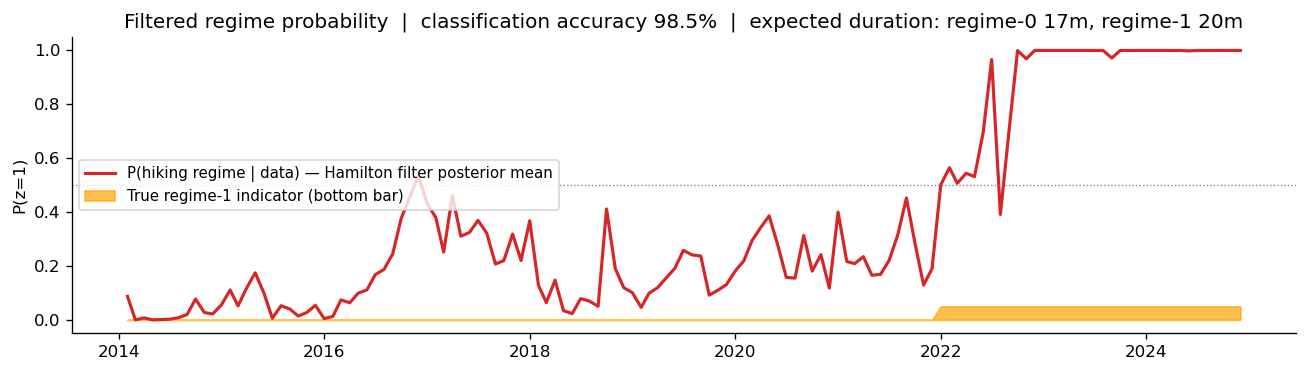

In [3]:
dates_filt = xi_filtered.index
p_hiking   = xi_filtered["P_regime_1"].values
true_r1    = (regime_true[1:] == 1).astype(int)
accuracy   = ((p_hiking > 0.5).astype(int) == true_r1).mean()

p00 = float(post["p00"].mean(("chain", "draw")).values)
p11 = float(post["p11"].mean(("chain", "draw")).values)

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(dates_filt, p_hiking, color="#d62728", lw=1.9,
        label="P(hiking regime | data) (Hamilton filter posterior mean)")
ax.fill_between(dates_filt, 0, true_r1 * 0.05,
                color="orange", alpha=0.7, label="True regime-1 indicator (bottom bar)")
ax.axhline(0.5, color="gray", lw=0.8, ls=":")
ax.set_ylim(-0.05, 1.05); ax.set_ylabel("P(z=1)")
ax.set_title(
    f"Filtered regime probability  |  classification accuracy {accuracy:.1%}  "
    f"|  expected duration: regime-0 {1/(1-p00):.0f}m, regime-1 {1/(1-p11):.0f}m"
)
ax.legend(fontsize=9, loc="center left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout(); plt.show()


In [4]:
gamma_mean  = post["gamma"].mean(("chain", "draw")).values
beta_L_mean = post["beta_L"].mean(("chain", "draw")).values   # (2, S)

rows = []
for s, seg in enumerate(SEGMENTS):
    half_life = -np.log(2) / np.log(1 + gamma_mean[s])
    rows.append({
        "Segment":             seg,
        "gamma (est)":         f"{gamma_mean[s]:+.3f}",
        "Half-life (months)":  f"{half_life:.1f}",
        "beta_L^0 (low rate)": f"{beta_L_mean[0, s]:.2f}",
        "beta_L^1 (hiking)":   f"{beta_L_mean[1, s]:.2f}",
        "Amplification":       f"{beta_L_mean[1, s] / max(beta_L_mean[0, s], 0.01):.1f}x",
    })
print("ECM repricing parameters (posterior mean):\n")
print(pd.DataFrame(rows).set_index("Segment").to_string())
print()
print("Reading the table:")
print(" - gamma is the monthly speed of adjustment toward equilibrium.")
print("   Corporate (-0.5) closes ~half the gap each month; retail current (-0.2)")
print("   takes 3 months to do the same. This matches the expected stickiness order.")
print(" - beta_L^1 / beta_L^0 shows how much pass-through expands in the hiking regime.")
print("   In the low-rate regime pass-through is essentially zero across segments;")
print("   in the hiking regime it ranges from ~0.13 (Retail Current) to ~0.66 (Corporate).")


ECM repricing parameters (posterior mean):

                gamma (est) Half-life (months) beta_L^0 (low rate) beta_L^1 (hiking) Amplification
Segment                                                                                           
Retail Current       -0.203                3.0                0.08              0.13          1.7x
Retail Savings       -0.204                3.0                0.08              0.29          3.5x
SME Operational      -0.310                1.9                0.15              0.43          2.9x
Corporate            -0.525                0.9                0.19              0.66          3.4x

Reading the table:
 - gamma is the monthly speed of adjustment toward equilibrium.
   Corporate (-0.5) closes ~half the gap each month; retail current (-0.2)
   takes 3 months to do the same. This matches the expected stickiness order.
 - beta_L^1 / beta_L^0 shows how much pass-through expands in the hiking regime.
   In the low-rate regime pass-through is es

---

## Part 3: Volumes: hierarchical AR(1) with regime-soft spread sensitivity

Rates aren't the whole story for NII. When market rates rise above what
depositors get paid, money walks: depositors shift funds to higher-yielding
alternatives (money-market funds, term deposits). Volumes contract.

### Model

Log-volumes follow a partial-adjustment AR(1) per segment:

$$
\log V_{s,t} \;=\; \alpha_s
\;+\; \rho_s \log V_{s,t-1}
\;+\; \beta_s(p_{t-1})\,\text{spread}_{s,t-1}
\;+\; \varepsilon_{s,t},
$$

with

$$
\text{spread}_{s,t} \;=\; y^{5\mathrm y}_t - r_{s,t}
\quad\text{(opportunity cost),}
$$

$$
\beta_s(p) \;=\; \beta^0_s + \Delta\beta_s\cdot p,
\qquad
\beta^0_s,\,\Delta\beta_s < 0.
$$

The interpretation:

- $\rho_s\in(0,1)$ represents **persistence**. Retail balances are sticky
  ($\rho \approx 0.98$); corporate balances less so ($\rho\approx 0.88$).
- $\beta^0_s$: spread sensitivity in the **low-rate regime** (mild).
- $\Delta\beta_s$ captures **additional** sensitivity in the hiking regime. The
  sign constraint $\Delta\beta_s<0$ forces total sensitivity to grow
  in absolute value during the hiking cycle (more disintermediation).

### Re-using stage 2's regime probabilities

We don't introduce a second latent state. Instead the regime probability
$p_{t-1}=P(z_{t-1}=1\mid\text{data})$ is taken directly from the Hamilton
filter of stage 2 and used as a **soft continuous covariate**. The volume
model inherits the regime dynamics from the rates model: no double-counting,
no second Hamilton filter.

### Hierarchical structure with non-funnel σ priors

Population-level priors share information across the 4 segments
($\mu_{\log|\beta^0|}, \sigma_{\log|\beta^0|}$ etc.), with non-centred
parameterisation for the segment-level draws. We use **LogNormal** priors on
the hyperparameter scales (rather than HalfNormal). This keeps prior density
at $\sigma = 0$ to zero, which kills the classic hierarchical "funnel"
divergence that arises with only 4 segments informing $\sigma$:

$$
\sigma_{\log|\beta^0|},\;\sigma_{\log|\Delta\beta|},\;\sigma_{\text{logit}\,\rho}
\;\sim\; \text{LogNormal}(\log 0.5,\;0.4).
$$

After this reparameterisation NUTS produces $\hat R = 1.00$ across all
top-level parameters with ESS bulk > 3000.

### NII

$$
\text{NII}_{s,t}\;=\;V_{s,t}\cdot\text{spread}_{s,t}/12.
$$

Summing across segments gives the monthly NII contribution from NMDs.


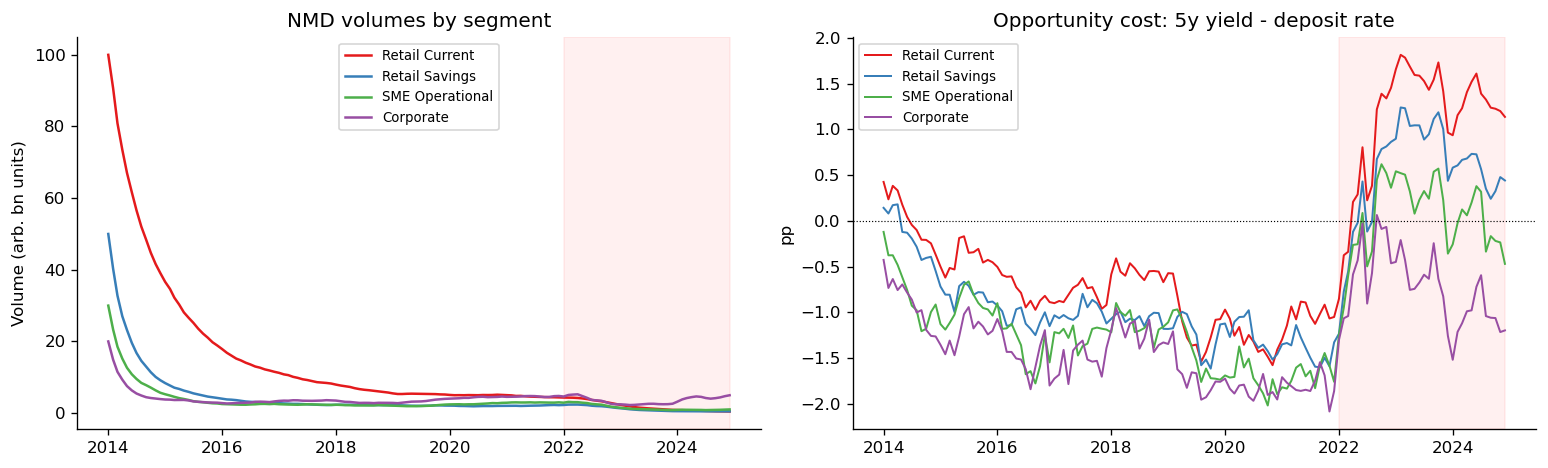

Volume change pre→post 2022 (segment-level disintermediation):
  Retail Current        :   16.9 ->   1.9  (-89%)
  Retail Savings        :    5.3 ->   1.1  (-79%)
  SME Operational       :    3.9 ->   1.5  (-61%)
  Corporate             :    4.1 ->   3.6  (-14%)


In [5]:
# Spread = 5y yield - deposit rate
spread = yields["60m"].values[:, None] - deposits.values
spread_df = pd.DataFrame(spread, index=dates, columns=SEGMENTS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for seg, c in zip(SEGMENTS, SEG_COLORS):
    ax.plot(dates, volumes_df[seg], color=c, lw=1.5, label=seg)
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
ax.set_title("NMD volumes by segment")
ax.set_ylabel("Volume (arb. bn units)")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax = axes[1]
for seg, c in zip(SEGMENTS, SEG_COLORS):
    ax.plot(dates, spread_df[seg], color=c, lw=1.2, label=seg)
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
ax.set_title("Opportunity cost: 5y yield - deposit rate")
ax.set_ylabel("pp")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout(); plt.show()

# Quick volume change pre/post 2022
print("Volume change pre→post 2022 (segment-level disintermediation):")
idx_post = dates >= "2022-01-01"
for seg in SEGMENTS:
    pre  = volumes_df.loc[~idx_post, seg].mean()
    post_v = volumes_df.loc[idx_post,  seg].mean()
    print(f"  {seg:<22}: {pre:6.1f} -> {post_v:5.1f}  ({(post_v/pre-1)*100:+.0f}%)")


In [6]:
post_v   = idata_vol.posterior
rho_v    = post_v["rho"].mean(("chain", "draw")).values
beta0_v  = post_v["beta0"].mean(("chain", "draw")).values
dbeta_v  = post_v["delta_beta"].mean(("chain", "draw")).values
beta1_v  = beta0_v + dbeta_v   # regime-1 spread sensitivity

rows = []
for s, seg in enumerate(SEGMENTS):
    rows.append({
        "Segment":         seg,
        "rho (est)":       f"{rho_v[s]:.3f}",
        "half-life (m)":   f"{-np.log(2)/np.log(rho_v[s]):.0f}",
        "beta_V^0":        f"{beta0_v[s]:+.4f}",
        "beta_V^1":        f"{beta1_v[s]:+.4f}",
        "amplification":   f"{abs(beta1_v[s] / beta0_v[s]):.1f}x",
    })
print("Volume model parameters (posterior mean):\n")
print(pd.DataFrame(rows).set_index("Segment").to_string())
print()
print("Reading the table:")
print(" - rho is the AR(1) persistence; the half-life is how long it takes")
print("   for a shock to log-volume to decay by half.")
print(" - beta_V^k < 0 means: wider spread (depositor sees better alternative)")
print("   => log-volume falls. beta_V^1 is steeper, so disintermediation is")
print("   faster in the hiking regime (exactly the behavioural story).")


Volume model parameters (posterior mean):

                rho (est) half-life (m) beta_V^0 beta_V^1 amplification
Segment                                                                
Retail Current      0.981            36  -0.0189  -0.0461          2.4x
Retail Savings      0.951            14  -0.0281  -0.0693          2.5x
SME Operational     0.928             9  -0.0406  -0.0848          2.1x
Corporate           0.895             6  -0.0613  -0.1608          2.6x

Reading the table:
 - rho is the AR(1) persistence; the half-life is how long it takes
   for a shock to log-volume to decay by half.
 - beta_V^k < 0 means: wider spread (depositor sees better alternative)
   => log-volume falls. beta_V^1 is steeper, so disintermediation is
   faster in the hiking regime — exactly the behavioural story.


---

## Part 4: IRRBB scenarios: rates and NII at the 12-month horizon

We take the last observed yield curve and apply five standard regulatory
rate shocks, linearly ramped over 12 months:

| Scenario | Shock at H=12 | Assumed regime |
|---|---|---|
| Baseline | none | weighted by current $P(z=1)$ |
| Parallel +200 bp | $\Delta L = +2.00$ | hiking (forced) |
| Parallel –100 bp | $\Delta L = -1.00$ | low rate (forced) |
| Steepener +100 bp | $\Delta S = +1.00$ | keep current |
| Flattener –100 bp | $\Delta S = -1.00$ | keep current |

Under each, we sample from the **full posterior predictive** of (i) the ECM
model, giving deposit rate trajectories per segment with sluggish adjustment,
and (ii) the volume model, giving volumes and NII. Posterior uncertainty is
carried through; we display the median and 80% predictive interval.


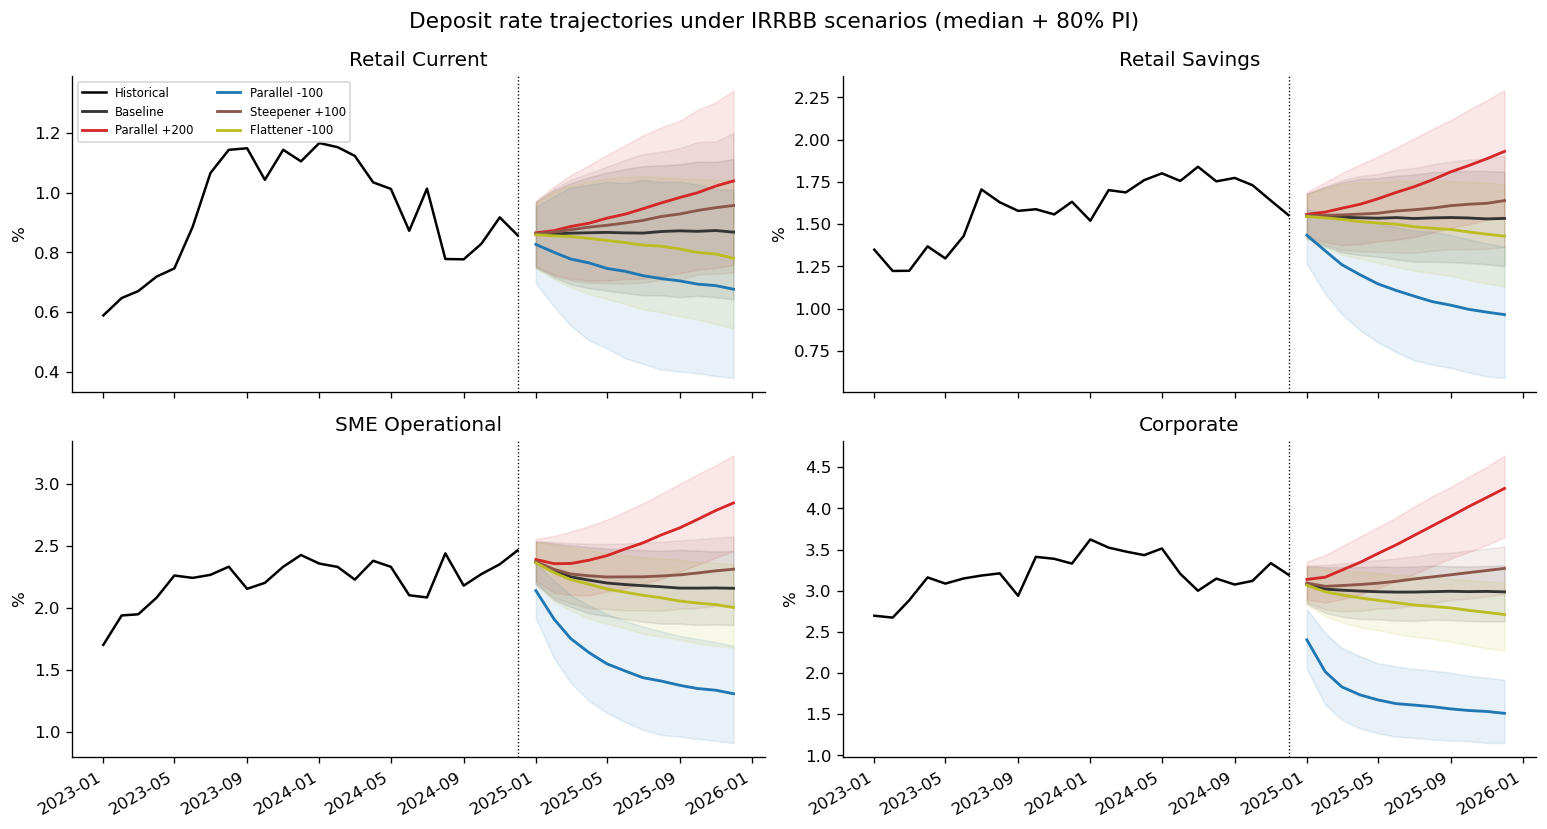

In [7]:
scenario_names    = pipe["scenario_names"]
scenario_deposits = pipe["scenario_deposits"]
forecast_dates    = pipe["forecast_dates"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for s, (ax, seg, c) in enumerate(zip(axes.flat, SEGMENTS, SEG_COLORS)):
    ax.plot(deposits.index[-24:], deposits[seg].iloc[-24:],
            color="black", lw=1.5, label="Historical")
    for (name, ppc), sc in zip(scenario_deposits.items(), SCENARIO_COLORS):
        med = np.median(ppc[:, :, s], axis=0)
        lo  = np.percentile(ppc[:, :, s], 10, axis=0)
        hi  = np.percentile(ppc[:, :, s], 90, axis=0)
        ax.fill_between(forecast_dates, lo, hi, color=sc, alpha=0.10)
        ax.plot(forecast_dates, med, color=sc, lw=1.7, label=name)
    ax.axvline(deposits.index[-1], color="black", lw=0.8, ls=":")
    ax.set_title(seg); ax.set_ylabel("%")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    if s == 0:
        ax.legend(fontsize=7, ncol=2)
fig.suptitle("Deposit rate trajectories under IRRBB scenarios (median + 80% PI)",
             fontsize=13)
fig.autofmt_xdate(rotation=30); fig.tight_layout(); plt.show()


In [8]:
# Headline 12m table: deposit rate by scenario × segment
rows = []
for name, ppc in scenario_deposits.items():
    medians = np.median(ppc[:, -1, :], axis=0)
    row = {"Scenario": name}
    for s, seg in enumerate(SEGMENTS):
        row[seg] = f"{medians[s]:.2f}%"
    rows.append(row)
print("Posterior median deposit rate at the 12-month horizon:\n")
print(pd.DataFrame(rows).set_index("Scenario").to_string())

# Cumulative pass-through under +200bp
ppc_base = scenario_deposits["Baseline"][:, -1, :]
ppc_up   = scenario_deposits["Parallel +200"][:, -1, :]
pt12     = np.median((ppc_up - ppc_base) / 2.0, axis=0)
print("\n12-month cumulative pass-through under Parallel +200 bp:")
for s, seg in enumerate(SEGMENTS):
    print(f"  {seg:<22}: {pt12[s]*100:5.1f}%")

print()
print("The pass-through fan-out across segments under +200bp")
print("({:.0f}% Retail Current to {:.0f}% Corporate) is the headline economic ".format(
    pt12[0]*100, pt12[3]*100,
))
print("output of the model: it directly drives IRRBB and NII sensitivity reports.")


Posterior median deposit rate at the 12-month horizon:

               Retail Current Retail Savings SME Operational Corporate
Scenario                                                              
Baseline                0.87%          1.53%           2.16%     2.99%
Parallel +200           1.04%          1.93%           2.85%     4.24%
Parallel -100           0.68%          0.96%           1.31%     1.51%
Steepener +100          0.96%          1.64%           2.31%     3.27%
Flattener -100          0.78%          1.43%           2.01%     2.71%

12-month cumulative pass-through under Parallel +200 bp:
  Retail Current        :   8.5%
  Retail Savings        :  19.7%
  SME Operational       :  34.8%
  Corporate             :  62.5%

The pass-through fan-out across segments under +200bp
(9% Retail Current to 62% Corporate) is the headline economic 
output of the model — it directly drives IRRBB and NII sensitivity reports.


---

## Technical highlights: what's novel

| Stage | Technique | Implementation detail |
|---|---|---|
| 1 | **Kalman filter inside NUTS** via `pytensor.scan` for the Diebold-Li state-space gives the exact marginal likelihood, differentiable end-to-end | `src/diebold_li.py` |
| 2 | **Hamilton filter inside NUTS** for the Markov-switching ECM, again as a differentiable `pytensor.scan` loop. Joint posterior over regime probabilities, transition matrix, and segment betas | `src/ecm_repricing.py` |
| 2 | **Identification constraint** $\delta>0$ via `HalfNormal` on the regime gap, breaking label-swap symmetry | `build_ecm_model` |
| 3 | **Soft regime covariate**: the volume model re-uses the Hamilton filter posterior probabilities from stage 2, avoiding a second latent state | `src/volume.py` |
| 3 | **LogNormal hyperparameter scales** instead of HalfNormal, which kills the hierarchical-funnel divergence that arises with only S=4 segments to inform $\sigma$ | `build_volume_model` |
| All | **JAX-compiled NUTS via numpyro** for fast sampling on CPU (this project does not require a GPU; an earlier Julia/DiffEqGPU prototype was abandoned for portability) | `nuts_sampler="numpyro"` |

## Code layout

```
src/
  data.py          ECB SDW REST API ingestion
  simulate.py      DGPs + true parameter constants
  diebold_li.py    Kalman state-space + extract_factors_numpy
  ecm_repricing.py Hamilton filter + extract_regime_probs_numpy
  volume.py        Hierarchical AR(1) volume model + NII
  repricing.py     Static repricing (legacy, kept for comparison)

notebooks/
  00_main.ipynb       (this summary notebook)
  01_theory.ipynb     full theoretical derivation
  02_data.ipynb       ECB ingestion + simulated deposits
  02_simulation.ipynb stand-alone synthetic DGP
  03_diebold_li.ipynb yield curve estimation
  04_repricing.ipynb  ECM regime-switching estimation
  05_pipeline.ipynb   scenario pass-through analysis
  06_volume.ipynb     volume model + scenario NII
```

Stack: PyMC 5.x, pytensor, NUTS via numpyro+JAX, arviz for diagnostics,
matplotlib for figures. Python 3.11 in conda env `pymc_env`.
